### Loaders

In [ ]:
from langchain_classic.document_loaders import TextLoader

# load the text data from a file using textloader
loader = TextLoader("sample.txt")
document = loader.load()
print(document)

In [ ]:
document[0].metadata

<b>Types of Document Loaders

Three types of document loaders:<br>
1. Transform Loader<br>
2. Public Dataset or Service Loaders<br>
3. Proprietary Dataset or Service Loader

<b> Transform Loader

In [ ]:
from langchain_classic.document_loaders import CSVLoader

loader = CSVLoader("file.csv")
documents = loader.load()

# acces the content and metadata of eacch document
for document in documents:
    content = document.page_content
    metadata = document.metadata

    print(content) 

<b> PDF Loader

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("file.pdf")
pages = loader.load()

In [ ]:
cnt = 0
for page in pages:
    cnt = cnt+1
    print(cnt)
    print(page.page_content.strip())


<b>WebBase Loader

In [2]:
from langchain_community.document_loaders import WebBaseLoader

loader = WebBaseLoader("https://www.bahria.edu.pk/")
data = loader.load()

In [3]:
data[0].page_content

'\n\n\n\n\n\nBahria University\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nBahria University\nDiscovering Knowledge\n\n\n\n\n ODL \nStudents\nAlumni\nSustainability\nQA\nCareers\nDownloads\nWEBMAIL\n\n\n\n\n\n\n\n☰\n\nAbout\nAcademics\nAdmissions\nResearch & Innovations\nInternational\nCampus\n\n\n\n\nDiscover Bahria University\n\n\n\n\n\n\n\n\n\n\n\nWelcome to \r\n                                Bahria University\r\n                            \n\r\n                                Bahria University is a federally chartered public sector university established by the Pakistan Navy in 2000. Bahria has steadily evolved into one of Pakistan’s premier higher education institutions. \r\n\r\n                                Learn More\n\n\n\n\n\n\n\n\n\n\n\nVision\nTo become a knowledge and creativity driven international university that contributes towards the development of society.\nMission\nTo ensure academic excellence through the deliverance of quality education and applied

In [4]:
# combine strip() with string formatting for basic formatting
formatted_text = data[0].page_content.strip().replace("\n\n","\n")
print(formatted_text)

Bahria University














Bahria University
Discovering Knowledge


 ODL 
Students
Alumni
Sustainability
QA
Careers
Downloads
WEBMAIL



☰
About
Academics
Admissions
Research & Innovations
International
Campus


Discover Bahria University





Welcome to 
                                Bahria University
                            

                                Bahria University is a federally chartered public sector university established by the Pakistan Navy in 2000. Bahria has steadily evolved into one of Pakistan’s premier higher education institutions. 

                                Learn More





Vision
To become a knowledge and creativity driven international university that contributes towards the development of society.
Mission
To ensure academic excellence through the deliverance of quality education and applied research in a collegiate environment having strong linkages with industry and international community to meet the social challenges.
RECTOR’S MESSAGE
Vi

In [5]:
# ising regular expression for more cleaning
import re

# remove unnecessary whitespace and multiple newlines
cleaned_text = re.sub(r"\s+","",formatted_text)
cleaned_text = re.sub(r"\n+","\n\n",formatted_text)
print(cleaned_text)

Bahria University

Bahria University

Discovering Knowledge

 ODL 

Students

Alumni

Sustainability

QA

Careers

Downloads

WEBMAIL

☰

About

Academics

Admissions

Research & Innovations

International

Campus

Discover Bahria University

Welcome to 

                                Bahria University

                            



                                Bahria University is a federally chartered public sector university established by the Pakistan Navy in 2000. Bahria has steadily evolved into one of Pakistan’s premier higher education institutions. 



                                Learn More

Vision

To become a knowledge and creativity driven international university that contributes towards the development of society.

Mission

To ensure academic excellence through the deliverance of quality education and applied research in a collegiate environment having strong linkages with industry and international community to meet the social challenges.

RECTOR’S MESSAGE

Vi

<b>JSON Loader

In [ ]:
from langchain_community.document_loaders import JSONLoader

import json
from pathlib import Path
from pprint import pprint
file_path  = "text.json"
data = json.loads(Path(file_path).read_text())

In [ ]:
pprint(data)

In [ ]:
loader = loader = JSONLoader(
    file_path="text.json",
    jq_schema=".employees[].email",
    text_content=False
)
data = loader.load()

<b> Public Dataset or Service Loaders

<b> Wikipedia Loaders

In [ ]:
from langchain_community.document_loaders import WikipediaLoader

loader = WikipediaLoader(
    query="Machine learning",
    lang="en"
)

docs = loader.load()

print(docs[0].page_content[:300])

<b>IMDB Movie Script Loader

In [1]:
from langchain_community.document_loaders import IMSDbLoader

loader = IMSDbLoader("https://imsdb.com/scripts/BlacKkKlansman.html")

data = loader.load()

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
# Remove unnecessary newlines and carriage returns
formatted_text = data[0].page_content[:5000].strip()

# Print the formatted text
print(formatted_text)

BLACKKKLANSMAN
                         
                         
                         
                         
                                      Written by

                          Charlie Wachtel & David Rabinowitz

                                         and

                              Kevin Willmott & Spike Lee








                         FADE IN:
                         
          SCENE FROM "GONE WITH THE WIND"
                         
          Scarlett O'Hara, played by Vivian Leigh, walks through the
          Thousands of injured Confederate Soldiers pulling back to
          reveal the Famous Shot of the tattered Confederate Flag in
          "Gone with the Wind" as The Max Stein Music Score swells from
          Dixie to Taps.
                         
                                   BEAUREGARD- KLAN NARRATOR (O.S.)
                       They say they may have lost the
                       Battle but they didn't lose The War.
                  

<b>Youtube Loader

In [5]:
from langchain_community.document_loaders import YoutubeLoader

loader = YoutubeLoader.from_youtube_url(
    "https://www.youtube.com/watch?v=QsYGlZkevEg", add_video_info=False
)
data = loader.load()

In [6]:
# format the text
fornatted_text = data[0].page_content[:1000].strip()

print(data)

[Document(metadata={'source': 'QsYGlZkevEg'}, page_content='LADIES AND GENTLEMEN, PEDRO PASCAL! [ CHEERS AND APPLAUSE ] >> THANK YOU, THANK YOU. THANK YOU VERY MUCH. I\'M SO EXCITED TO BE HERE. THANK YOU. I SPENT THE LAST YEAR SHOOTING A SHOW CALLED "THE LAST OF US" ON HBO. FOR SOME HBO SHOES, YOU GET TO SHOOT IN A FIVE STAR ITALIAN RESORT SURROUNDED BY BEAUTIFUL PEOPLE, BUT I SAID, NO, THAT\'S TOO EASY. I WANT TO SHOOT IN A FREEZING CANADIAN FOREST WHILE BEING CHASED AROUND BY A GUY WHOSE HEAD LOOKS LIKE A GENITAL WART. IT IS AN HONOR BEING A PART OF THESE HUGE FRANCHISEs LIKE "GAME OF THRONES" AND "STAR WARS," BUT I\'M STILL GETTING USED TO PEOPLE RECOGNIZING ME. THE OTHER DAY, A GUY STOPPED ME ON THE STREET AND SAYS, MY SON LOVES "THE MANDALORIAN" AND THE NEXT THING I KNOW, I\'M FACE TIMING WITH A 6-YEAR-OLD WHO HAS NO IDEA WHO I AM BECAUSE MY CHARACTER WEARS A MASK THE ENTIRE SHOW. THE GUY IS LIKE, DO THE MANDO VOICE, BUT IT\'S LIKE A BEDROOM VOICE. WITHOUT THE MASK, IT JUST SOUNDS

In [ ]:
# We can add video preference and language preferrences

loader = YoutubeLoader.from_youtube_url(
    "https://www.youtube.com/watch?v=1W8o0F_l6hA",
    add_video_info=True,
    language=["en", "id"],
    translation="en",
)
ytdata = loader.load()

# formatted text
formatted_text = ytdata[0].page_content[:5000].strip()

# Print the formatted text
print(formatted_text)

### Text Splitters

Transform the data for our project. At a high level, text splitters work as following:<br>
1. Split the text up into small, semantically meaningful chunks(often sentences)<br>
2. Start the combining these small chunks into a larger chunk until we reach a certain size( as measured by some function).<br>
3. Once we reach that size, make the chunk its own piece of text and then start creating a new chunk of text with some overlap(to keep context between chunks)

That means that there are two different axes which we can customize our text splitter<br>
1. How the text is split<br>
2. How the chunk size is measured<br>

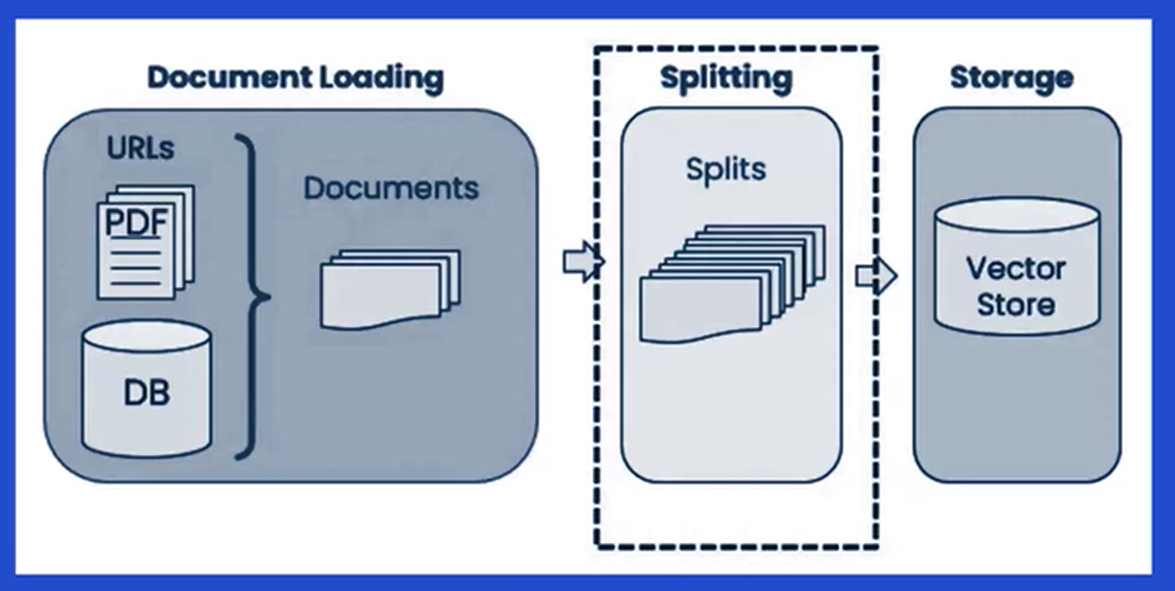

In [24]:
from langchain_classic.text_splitter import CharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
text_splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size = 200,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)

In [25]:
loader = WebBaseLoader("https://imsdb.com/scripts/BlacKkKlansman.html")
data = loader.load()

In [26]:
chunks = text_splitter.split_text(data[0].page_content)
len(chunks)

Created a chunk of size 310385, which is longer than the specified 200


6

In [27]:
for chunk in chunks:
    print(chunk)

The Internet Movie Script Database (IMSDb)


 

The web's largest movie script resource!

Search IMSDb

 


Alphabetical

#
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z


Genre
Genre

Action
Adventure
Animation
Comedy
Crime
Drama
Family
Fantasy
Film-Noir
Horror
Musical
Mystery
Romance
Sci-Fi
Short
Thriller
War
Western


Sponsor


TV Transcripts
TV Transcripts

Futurama
Seinfeld
South Park
Stargate SG-1
Lost
The 4400


International

French scripts


Latest Comments


ALL SCRIPTS
BLACKKKLANSMAN
                         
                         
                         
                         
                                      Written by

                          Charlie Wachtel & David Rabinowitz

                                         and

                              Kevin Willmott & Spike Lee








                         FADE IN:
                         
          SCENE FROM "GONE WITH THE WIND"
                         
          Scarlett O'Hara, played by Vi

In [28]:
documents    = text_splitter.create_documents([data[0].page_content])
len(documents)

Created a chunk of size 310385, which is longer than the specified 200


6

In [29]:
for doc in documents:
    print(doc)

page_content='The Internet Movie Script Database (IMSDb)


 

The web's largest movie script resource!

Search IMSDb

 


Alphabetical

#
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z


Genre'
page_content='Genre

Action
Adventure
Animation
Comedy
Crime
Drama
Family
Fantasy
Film-Noir
Horror
Musical
Mystery
Romance
Sci-Fi
Short
Thriller
War
Western


Sponsor


TV Transcripts'
page_content='TV Transcripts

Futurama
Seinfeld
South Park
Stargate SG-1
Lost
The 4400


International

French scripts


Latest Comments


ALL SCRIPTS'
page_content='BLACKKKLANSMAN
                         
                         
                         
                         
                                      Written by

                          Charlie Wachtel & David Rabinowitz

                                         and

                              Kevin Willmott & Spike Lee








                         FADE IN:
                         
          SCENE FROM "GONE WITH THE WIND"
      

<b>Recursive Character Text Splitter

Unlike a basic text splitter that blindly cuts your document every $X$ characters or looks for only one specific symbol, the recursive splitter is hierarchical. It uses a list of fallback separators to slice up your text as naturally as possible, preserving paragraphs, sentences, and words without breaking them in half.

"\n\n" (Double newlines / Paragraphs)

"\n" (Single newlines / Lines)

" " (Spaces / Words)

"" (Individual characters / Letters)

In [30]:
from langchain_classic.text_splitter import RecursiveCharacterTextSplitter

rectext_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 200,
    chunk_overlap=20,
    length_function=len,
    is_separator_regex=False,
)

In [32]:
texts = rectext_splitter.create_documents([data[0].page_content])
for text in texts:
    print(text)

page_content='The Internet Movie Script Database (IMSDb)




 

The web's largest movie script resource!











Search IMSDb

 








Alphabetical'
page_content='Alphabetical

#
A
B
C
D
E
F
G
H
I
J
K
L
M
N
O
P
Q
R
S
T
U
V
W
X
Y
Z




Genre'
page_content='Genre

Action
Adventure
Animation
Comedy
Crime
Drama
Family
Fantasy
Film-Noir
Horror
Musical
Mystery
Romance
Sci-Fi
Short
Thriller
War
Western




Sponsor








TV Transcripts'
page_content='TV Transcripts

Futurama
Seinfeld
South Park
Stargate SG-1
Lost
The 4400




International

French scripts




Latest Comments




ALL SCRIPTS'
page_content='BLACKKKLANSMAN'
page_content='Written by

                          Charlie Wachtel & David Rabinowitz

                                         and'
page_content='Kevin Willmott & Spike Lee








                         FADE IN:
                         
          SCENE FROM "GONE WITH THE WIND"'
page_content='Scarlett O'Hara, played by Vivian Leigh, walks through the
          Tho